# phase2 / notebook 1 — initial GNN architecture sweep

First model-selection experiment: 16-combination grid sweep across four model types, one optimizer (Adam), and two learning rates at modest hidden width.

# 1. Overview

## 1.1 Task & motivation

Pick a winning architecture from {FeedFwd, GraphConv, GraphSAGE, GraphAttention} at the cheapest viable hyperparameter setting (single hidden layer, 100 epochs).

## 1.2 Dataset summary

Reddit2 (same as phase 1). `NeighborLoader` with `[20, 15, 10]` sampling sizes.

## 1.3 Approach in one paragraph

Define a grid of 16 `(model, lr, dropout)` combinations and train each for 100 epochs. Collect per-run training/validation loss curves; rank by final validation loss; plot the top runs.

## 1.4 Libraries used

| Library | Used for |
|---|---|
| `torch`, `torch_geometric`, `torch_sparse` | GNN building blocks |
| `nnx` | Model and training abstractions |

# 2. Environment & Setup

## 2.1 Imports

Cell 0 imports torch, PyG, nnx primitives.

## 2.2 Configuration / hyperparameters

`N_NEIGHBORS = [20, 15, 10]`, `n_heads = 4` (GAT), `n_epochs = 100`. Single hidden layer `[128]`.

## 2.3 Reproducibility (seed, device)

`nnx` handles seeding; device defaults to GPU when present.

# 3. Data

## 3.1 Loading

Cell 1: `pyg.datasets.Reddit2(root="./data")`.

## 3.2 Inspection / EDA

Covered in phase 1.

## 3.3 Preprocessing & splits

PyG defaults: 153,932 train / 23,699 val / 55,334 test.

# 4. Model

## 4.1 Architecture

Four architectures swept (FeedFwd, GraphConv, GraphSAGE, GraphAttention), each with hidden dim `[128]`.

## 4.2 Loss & optimizer

Cross-entropy. Optimizer: `Optims.ADAM`. Learning rates: `{1e-2, 1e-4}`.

## 4.3 Why this design

Smallest hidden dim and shortest training that can still discriminate architectures, to keep the 16-way sweep tractable.

# 5. Training

## 5.1 Training loop

`nnx` loop, 100 epochs per combination. Per-run `train_idps` stored in `trains` dict.

## 5.2 Metrics tracked

Per-iteration training and validation loss.

## 5.3 Run-time notes

Tier B (~57 minutes for the full sweep on the original M1 Max). Original outputs preserved.

# 6. Evaluation & Results

## 6.1 Test-set evaluation

Top runs by final validation loss collected in `top_model_names`.

## 6.2 Visualizations

`Utils.multi_line_plot` (cells 6, 7) renders training and validation loss curves for the top runs.

## 6.3 Discussion

GraphAttention dominated this sweep. Cell 8 prints the winner. Resource analysis: GAT memory-bottlenecked at higher hidden dims — informs phase 2 / notebook 3's design.


In [1]:
import torch_geometric as pyg


from nnx.utils import Utils
from nnx.nn.params.nn_params import NNParams
from nnx.nn.nn_model import NNModel
from nnx.nn.params.nn_train_params import NNTrainParams
from nnx.nn.enum.optims import Optims
from nnx.nn.params.nn_optim_params import NNOptimParams
from nnx.nn.params.nn_model_params import NNModelParams
from nnx.nn.enum.devices import Devices
from nnx.nn.enum.losses import Losses
from nnx.nn.enum.nets import Nets


In [2]:
dataset = pyg.datasets.Reddit2(
    root="./data"
    , transform=pyg.transforms.Compose(
        [
            pyg.transforms.NormalizeFeatures()
            , pyg.transforms.ToSparseTensor()
        ]
    )
)

In [3]:
N_NEIGHBORS = [20, 15, 10]

train_loader = pyg.loader.NeighborLoader(
    data=dataset._data
    , shuffle=True
    , num_workers=4
    , num_neighbors=N_NEIGHBORS
    , input_nodes=dataset._data.train_mask
    , batch_size=int(dataset._data.train_mask.sum())
)

val_loader = pyg.loader.NeighborLoader(
    data=dataset._data
    , shuffle=False
    , num_workers=4
    , num_neighbors=N_NEIGHBORS
    , input_nodes=dataset._data.val_mask
    , batch_size=int(dataset._data.val_mask.sum())
)

print(len(val_loader.dataset))
print(len(train_loader.dataset))

/opt/conda/lib/python3.10/site-packages/torch_geometric/sampler/neighbor_sampler.py:50: UserWarning: Using '{self.__class__.__name__}' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  warnings.warn("Using '{self.__class__.__name__}' without a "


23699
153932


In [4]:
n_heads = 4
n_epochs = 100
optims = [Optims.ADAM]
lrs = [1e-2, 1e-4]
weight_decay = 5e-4

dropout_probs = [0.25, 0.5]
hidden_dimss = [
    [128]
]

# (Nets enum, n_heads-or-None) tuples. Only GAT consumes n_heads; siblings ignore it.
net_specs = [
    (Nets.GRAPH_ATT,  n_heads),
    (Nets.GRAPH_SAGE, None),
    (Nets.GRAPH_CONV, None),
    (Nets.FEED_FWD,   None),
]

models = [
    NNModel(
        params=NNModelParams(
            net=net_enum,
            device=Devices.CPU,
            loss=Losses.CROSS_ENTROPY,
        ),
        net_params=NNParams(
            n_heads=heads,
            hidden_dims=hidden_dims,
            dropout_prob=dropout_prob,
            input_dim=dataset.num_features,
            output_dim=dataset.num_classes,
        ),
    )
        for hidden_dims in hidden_dimss
        for dropout_prob in dropout_probs
        for (net_enum, heads) in net_specs
]

train_params = [
    NNTrainParams(
        n_epochs=n_epochs,
        optim=NNOptimParams(name=optim, max_lr=lr, weight_decay=weight_decay),
    )
        .with_train_loader(value=train_loader)
        .with_val_loader(value=val_loader)
        for lr in lrs
        for optim in optims
]


In [5]:
trains = {
    train_str: (model, train_idps)
        for model, (train_str, train_idps) in [
            (model, model.train(params=train_param))
                for model in models
                for train_param in train_params
        ]
}

GraphAttNN={dims=[602, 128, 41], dropout=0.25, heads=4} x Train=[epochs=100, optim=adam, lr=1e-02, weight_decay=5e-04]: 100%|██████████| 100/100 [57:25<00:00, 34.45s/it, error: 0.3545]
GraphAttNN={dims=[602, 128, 41], dropout=0.25, heads=4} x Train=[epochs=100, optim=adam, lr=1e-04, weight_decay=5e-04]: 100%|██████████| 100/100 [1:05:22<00:00, 39.22s/it, error: 0.3265]
GraphAttNN={dims=[602, 128, 41], dropout=0.50, heads=4} x Train=[epochs=100, optim=adam, lr=1e-02, weight_decay=5e-04]: 100%|██████████| 100/100 [58:42<00:00, 35.23s/it, error: 0.4108]
GraphAttNN={dims=[602, 128, 41], dropout=0.50, heads=4} x Train=[epochs=100, optim=adam, lr=1e-04, weight_decay=5e-04]: 100%|██████████| 100/100 [1:03:41<00:00, 38.21s/it, error: 0.3440]
GraphSageNN={dims=[602, 128, 41], dropout=0.25} x Train=[epochs=100, optim=adam, lr=1e-02, weight_decay=5e-04]: 100%|██████████| 100/100 [27:09<00:00, 16.29s/it, error: 0.5954]
GraphSageNN={dims=[602, 128, 41], dropout=0.25} x Train=[epochs=100, optim=adam

In [6]:
top_model_names = [
    kvp[0] for kvp in sorted(
        list(trains.items())
        , key=lambda kvp: min(
            kvp[1][1]
            , key=lambda idp: idp.val_error
        ).val_error
    )[:10]
]

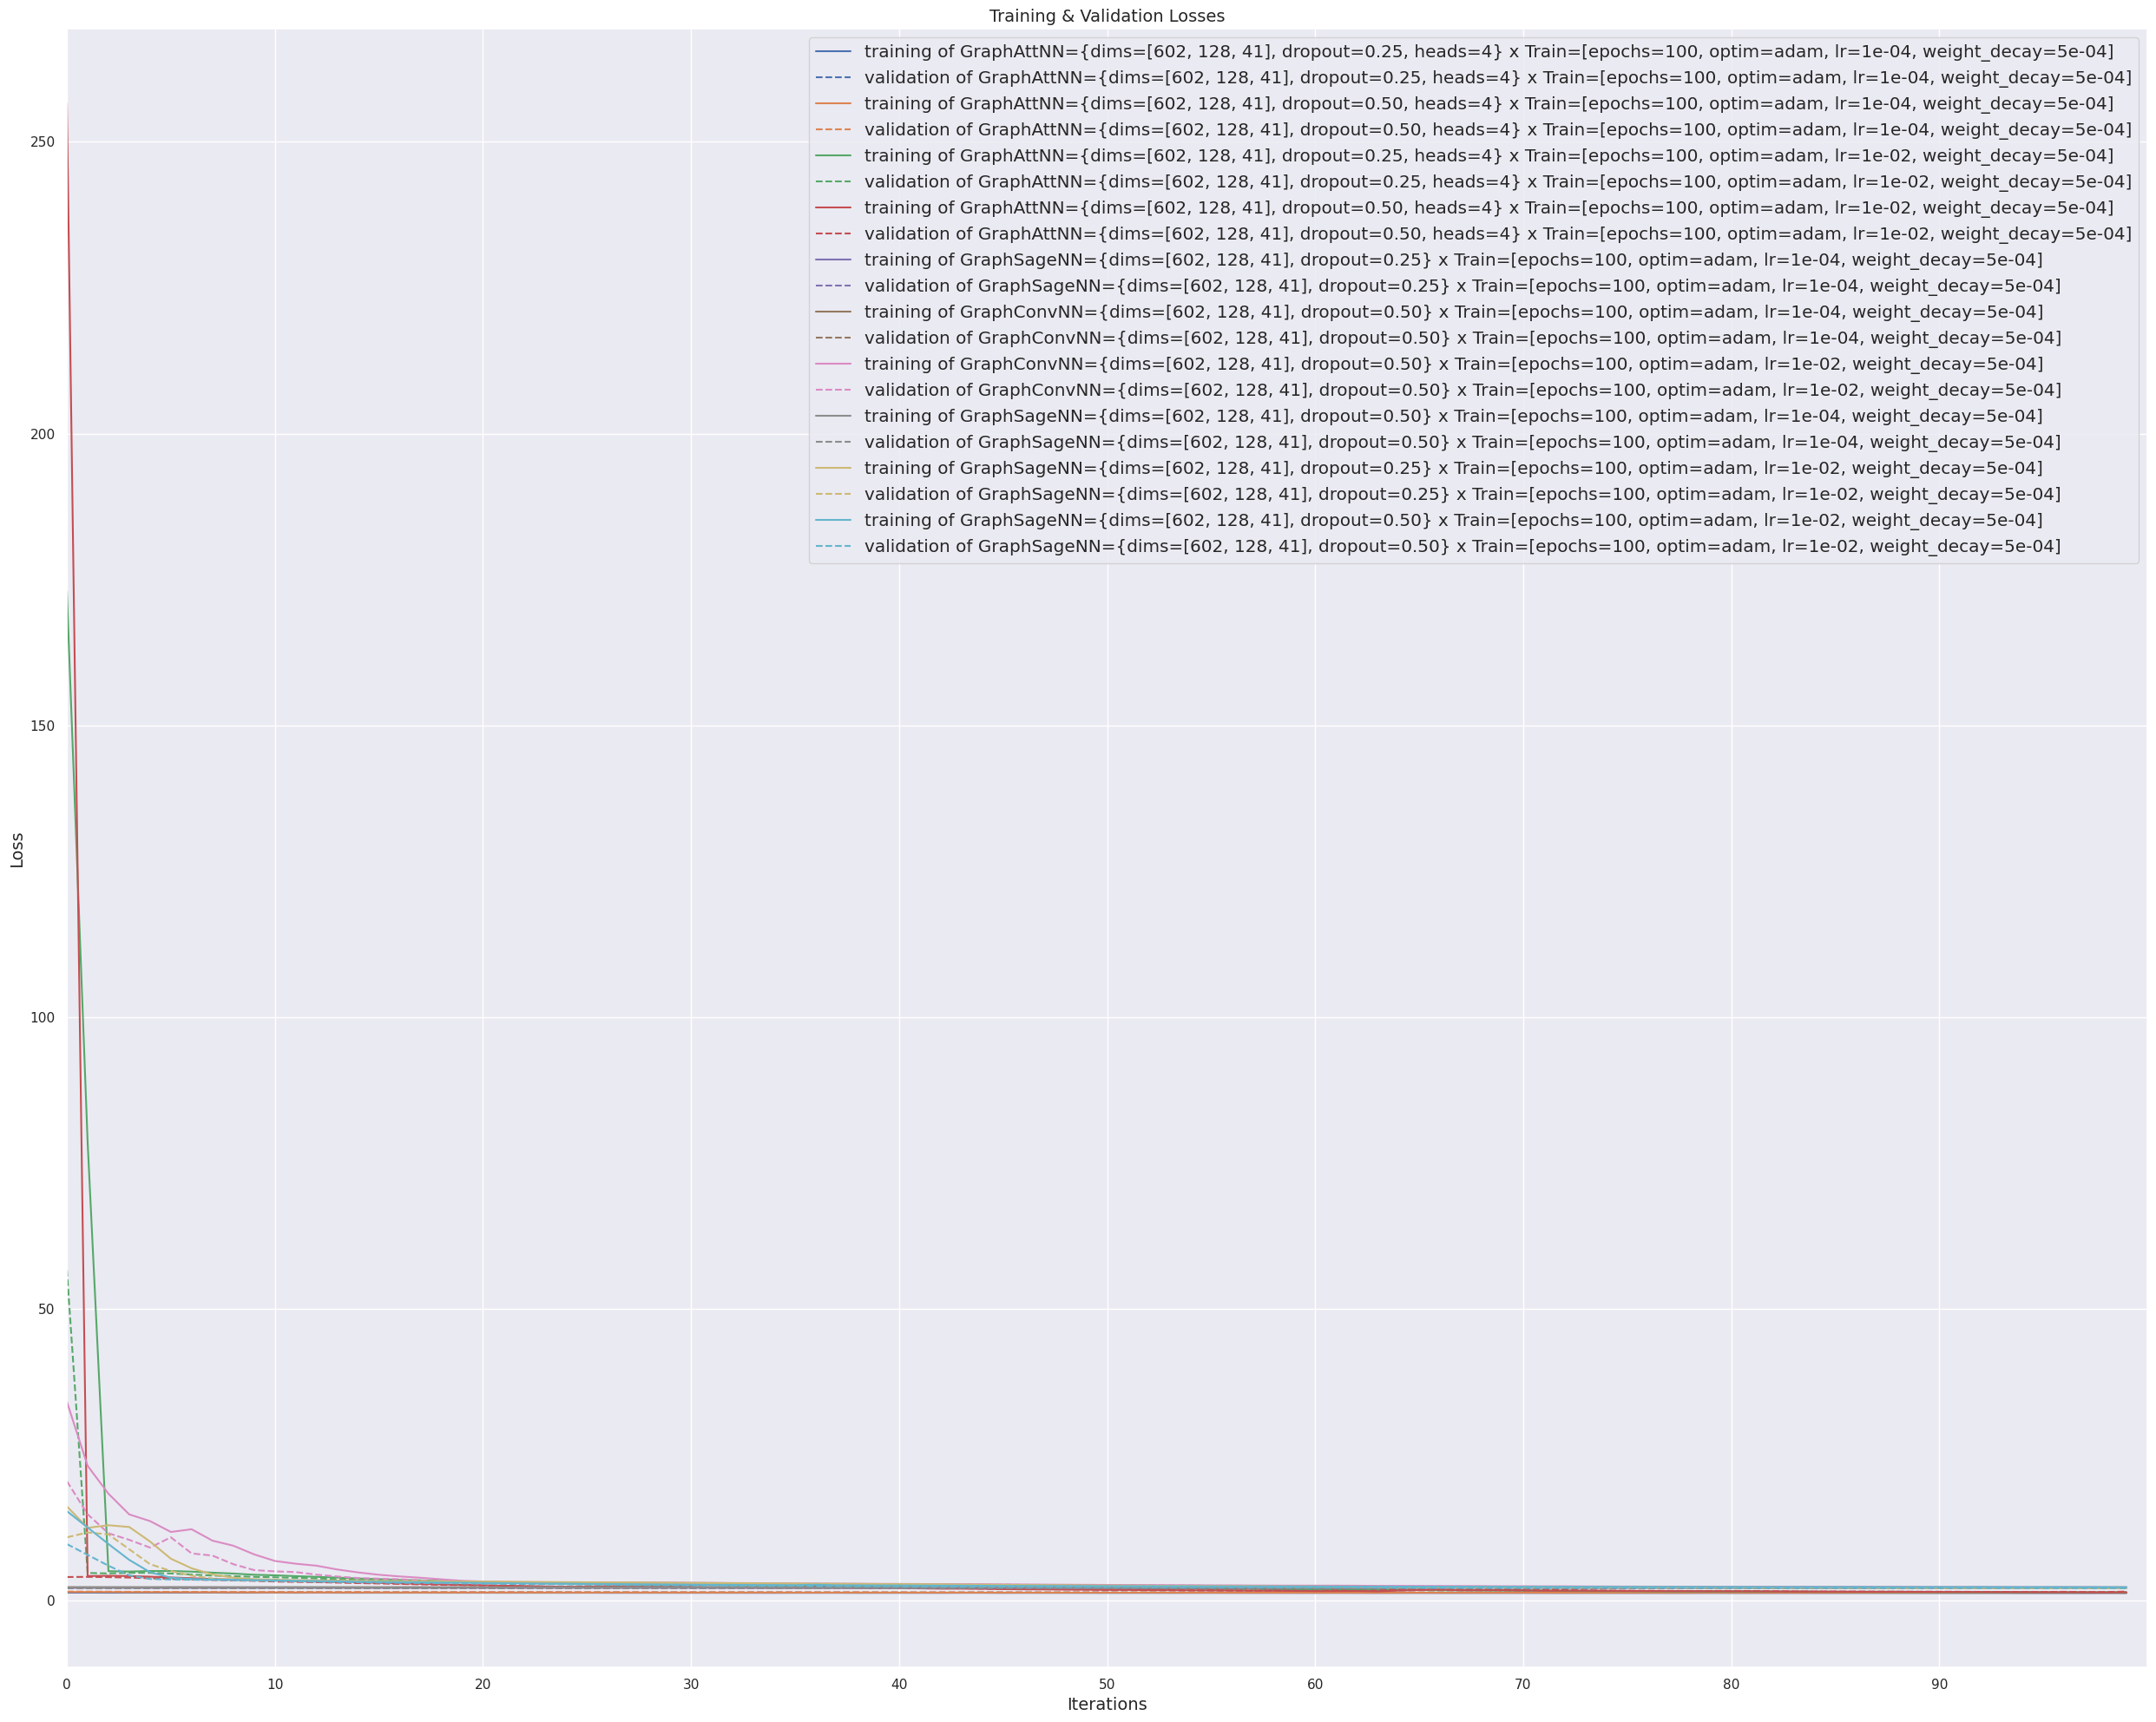

In [7]:
Utils.multi_line_plot(
    x_ticks_inc=10
    , fig_size=(25, 20)
    , y_axis_label="Loss"
    , x_axis_label="Iterations"
    , title="Training & Validation Losses"
    , x=[idp.iter_idx for idp in trains[top_model_names[0]][1]]
    , yss_legend=[[f"{loss_type} of {model_name}" for loss_type in ["training", "validation"]] for model_name in top_model_names]
    , yss=[[[model_idp.train_loss for model_idp in trains[model_name][1]], [model_idp.val_loss for model_idp in trains[model_name][1]]] for model_name in top_model_names]
)

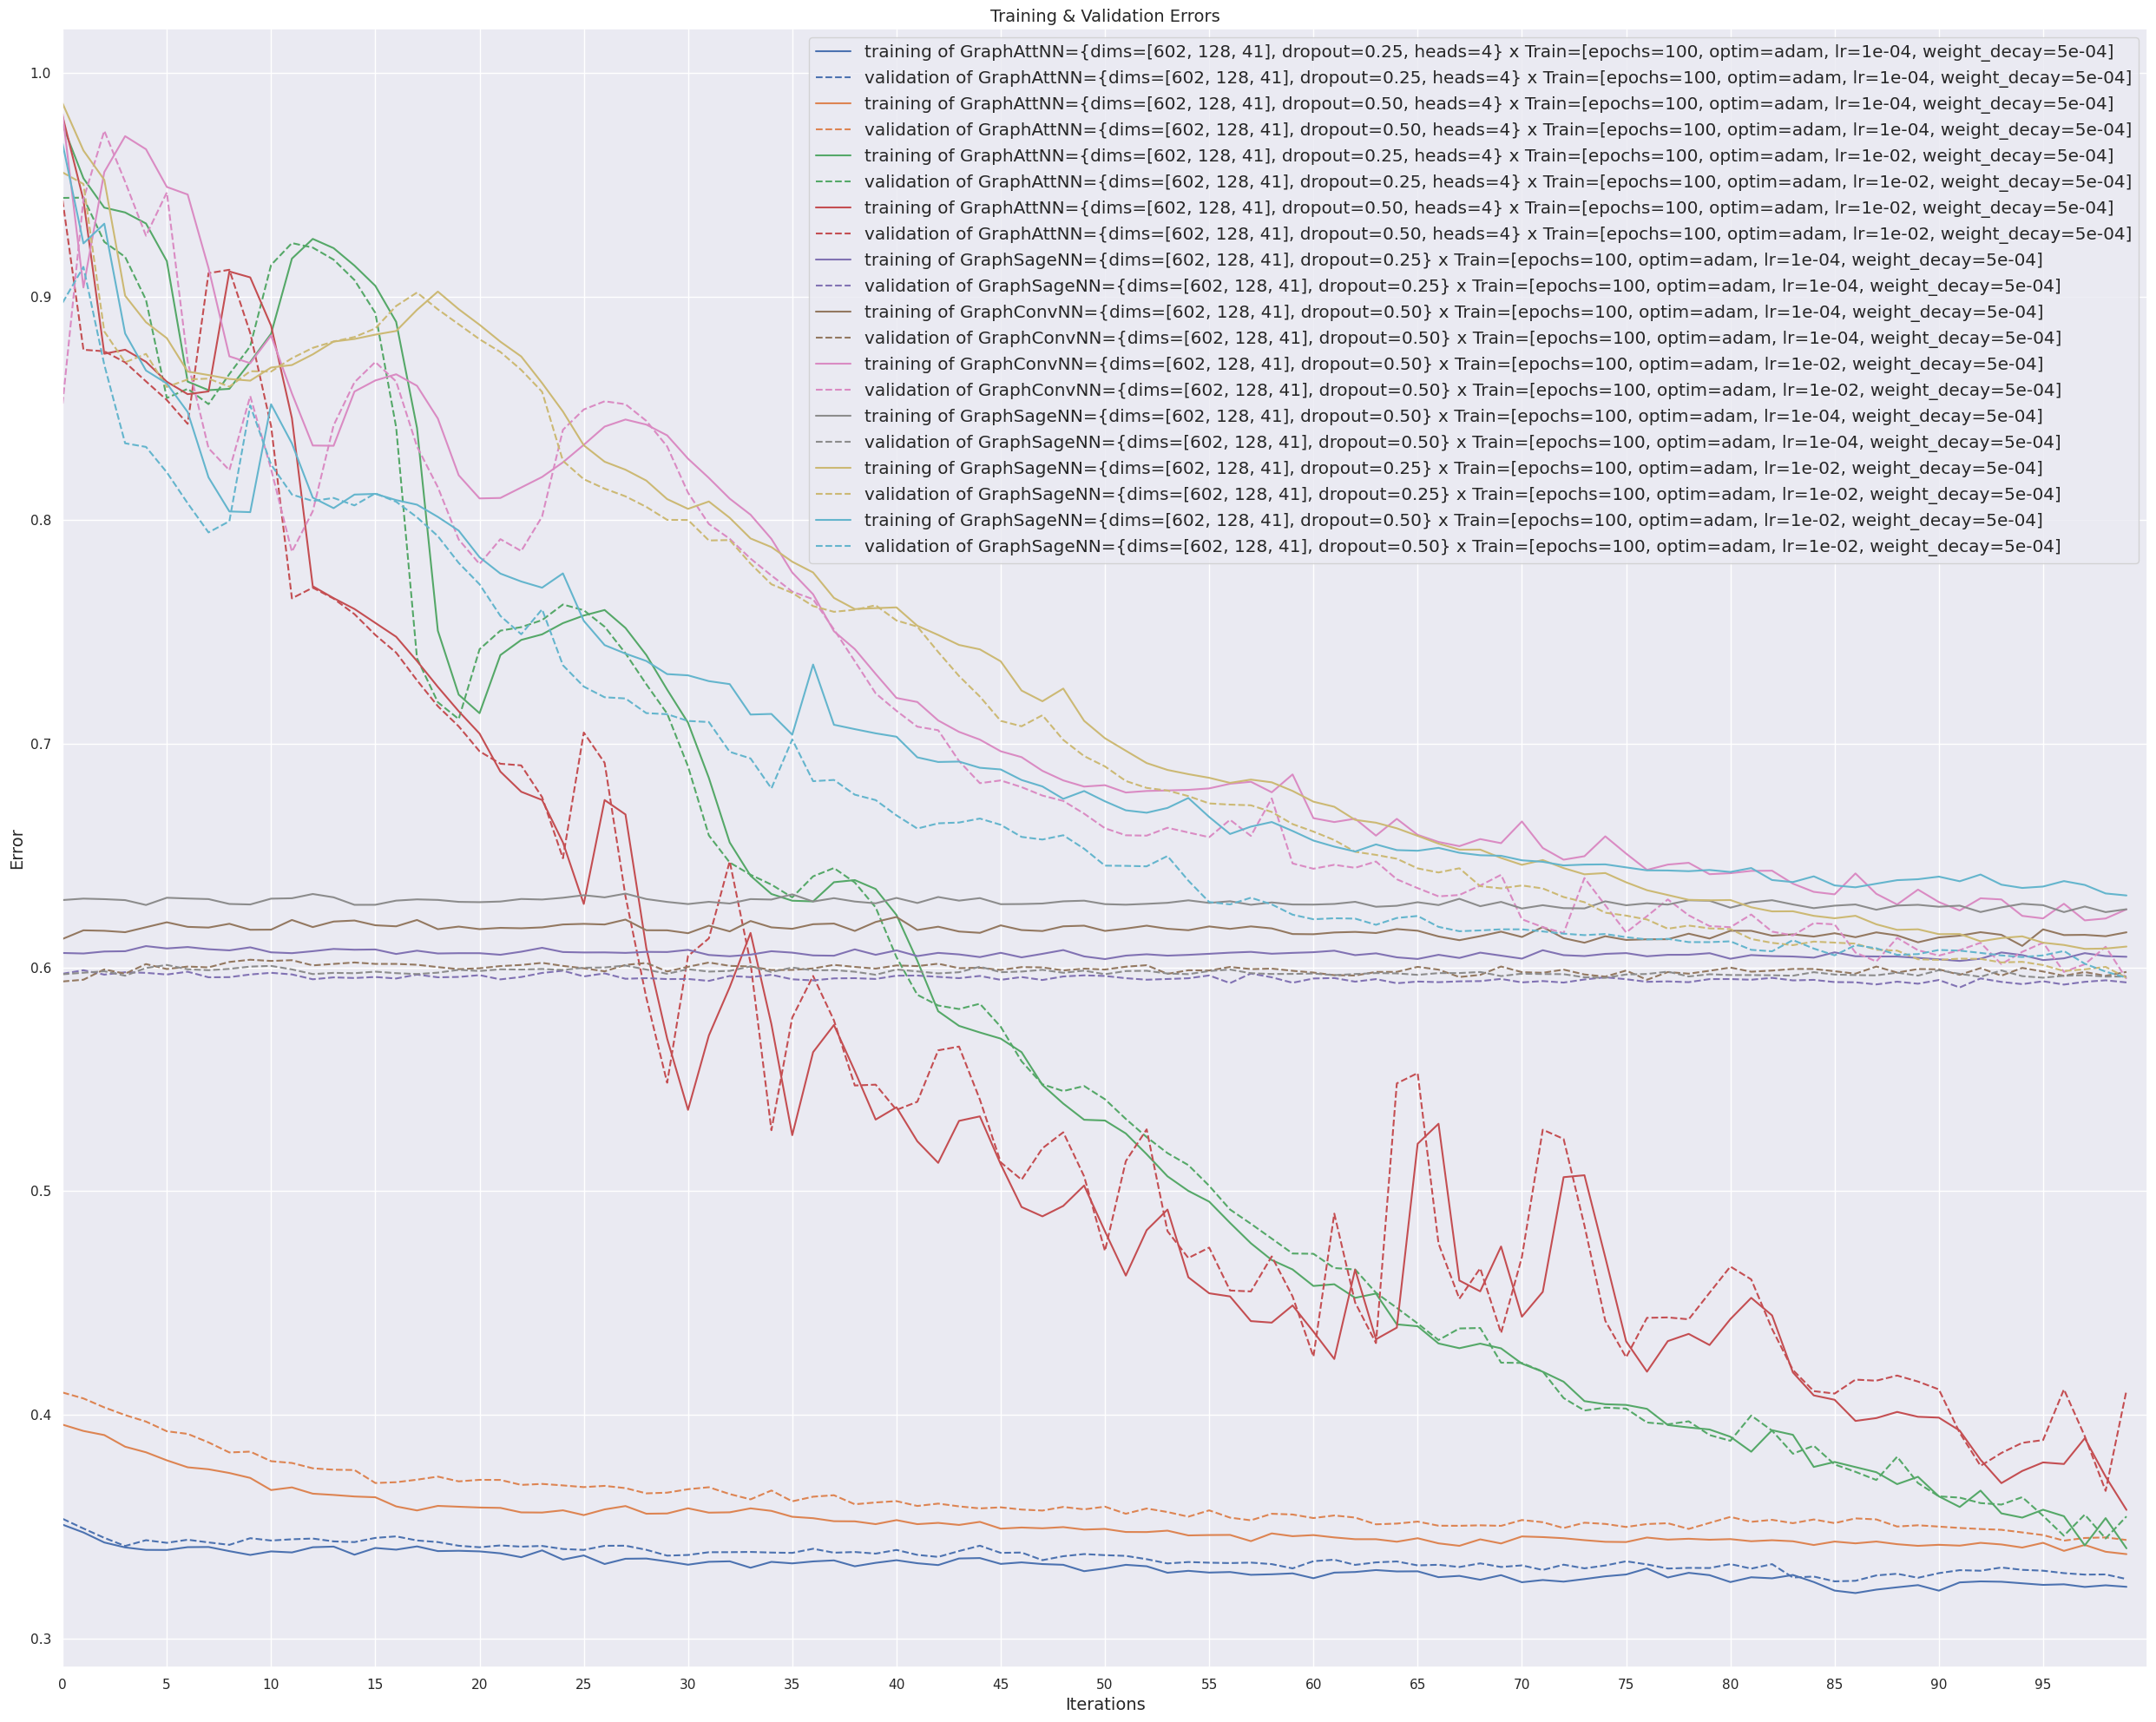

In [8]:
Utils.multi_line_plot(
    x_ticks_inc=5
    , fig_size=(25, 20)
    , y_axis_label="Error"
    , x_axis_label="Iterations"
    , title="Training & Validation Errors"
    , x=[idp.iter_idx for idp in trains[top_model_names[0]][1]]
    , yss_legend=[[f"{loss_type} of {model_name}" for loss_type in ["training", "validation"]] for model_name in top_model_names]
    , yss=[[[model_idp.train_error for model_idp in trains[model_name][1]], [model_idp.val_error for model_idp in trains[model_name][1]]] for model_name in top_model_names]
)

In [9]:
print(f"best model is {top_model_names[0]} which achieves validation error of {min(trains[top_model_names[0]][1], key=lambda idp: idp.val_error).val_error:.4f}")

best model is GraphAttNN={dims=[602, 128, 41], dropout=0.25, heads=4} x Train=[epochs=100, optim=adam, lr=1e-04, weight_decay=5e-04] which achieves validation error of 0.3255
